Code for simulation of the Posner attentional cueing task in Chapter 6 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter6.pdf).

In [80]:
import numpy as np
import matplotlib.pyplot as plt

In [81]:
# set random seed for reproducibility
np.random.seed(12)

In [82]:
class PosnerModel:
    def __init__(self, n_neurons=50, rate_high=50, rate_low=5, 
                 dt=0.001, capacitance=10, threshold=15):
        """
        Initializes the Neural/Bayesian Posner Model.
        
        Args:
            n_neurons (int): Number of neurons in the encoding population.
            rate_high (float): Firing rate (Hz) for preferred stimulus.
            rate_low (float): Firing rate (Hz) for non-preferred stimulus.
            dt (float): Simulation time step (seconds).
            capacitance (float): Membrane capacitance (C), scales integration.
            threshold (float): Decision threshold magnitude (+/-).
        """
        self.n_neurons = n_neurons
        self.rate_high = rate_high
        self.rate_low = rate_low
        self.dt = dt
        self.C = capacitance
        self.threshold = threshold
        
        # Define the population:
        # Half of neurons prefer 'Left', half prefer 'Right'
        self.half_n = n_neurons // 2
        
        # Calculate optimal weights (Eq. 2 in text)
        # w_d = log(f_d(Left) / f_d(Right))
        # For Left-preferring neurons: log(high/low) -> positive weight
        # For Right-preferring neurons: log(low/high) -> negative weight
        w_left_pref = np.log(rate_high / rate_low)
        w_right_pref = np.log(rate_low / rate_high)
        
        self.weights = np.concatenate([
            np.full(self.half_n, w_left_pref),
            np.full(self.half_n, w_right_pref)
        ])

    def get_firing_rates(self, target_loc):
        """Returns the firing rates for the population given the target location."""
        if target_loc == 'Left':
            # Left-pref neurons fire high, Right-pref fire low
            rates = np.concatenate([
                np.full(self.half_n, self.rate_high),
                np.full(self.half_n, self.rate_low)
            ])
        elif target_loc == 'Right':
            # Left-pref fire low, Right-pref fire high
            rates = np.concatenate([
                np.full(self.half_n, self.rate_low),
                np.full(self.half_n, self.rate_high)
            ])
        else:
            raise ValueError("Target location must be 'Left' or 'Right'")
        return rates

    def simulate_trial(self, cue_type, target_loc, max_time=2.0):
        """
        Simulates a single trial.
        
        Args:
            cue_type (str): 'Valid', 'Invalid', or 'Neutral'.
            target_loc (str): 'Left' or 'Right'.
        
        Returns:
            rt (float): Reaction time in seconds.
            mu_trajectory (array): History of membrane potential.
        """
        # 1. Set Prior (Initial Condition mu^0) - Eq. 4
        # P(Valid) = 0.8, P(Invalid) = 0.2, P(Neutral) = 0.5
        # mu^0 = log(P(Left|Cue) / P(Right|Cue))
        
        prior_prob = 0.5 # Default for Neutral
        
        if cue_type == 'Neutral':
            prior_prob = 0.5
        elif cue_type == 'Valid':
            # If target is Left, Cue was Left (implies high prior for Left)
            # If target is Right, Cue was Right (implies high prior for Right -> low Prob(Left))
            prior_prob = 0.8 if target_loc == 'Left' else 0.2
        elif cue_type == 'Invalid':
            # If target is Left, Cue was Right (implies low prior for Left)
            prior_prob = 0.2 if target_loc == 'Left' else 0.8
            
        # Calculate log odds
        mu = np.log(prior_prob / (1 - prior_prob))
        
        # 2. Simulation Loop
        time_steps = int(max_time / self.dt)
        rates = self.get_firing_rates(target_loc)
        mu_trajectory = [mu]
        
        for t in range(time_steps):
            # Generate spikes (Poisson process)
            # Probability of spike in dt = rate * dt
            spikes = np.random.rand(self.n_neurons) < (rates * self.dt)
            
            # Calculate Input Current I(t) - Eq. 1
            # I(t) = sum(w_d * z_d)
            current = np.sum(self.weights * spikes)
            
            # Integrate Membrane Potential - Eq. 3
            # C * dmu/dt = I(t)  =>  dmu = (I(t)/C) * dt
            d_mu = (current / self.C) # Note: dt is handled in spike generation or integration
            # To be precise with the text's differential equation:
            # We treat the current 'I' as a momentary impulse over the step dt.
            # Effectively adding the weighted spike count to the potential.
            mu += d_mu
            
            mu_trajectory.append(mu)
            
            # Check Thresholds
            # Positive threshold -> Detect Left
            # Negative threshold -> Detect Right
            if mu >= self.threshold:
                return t * self.dt, mu_trajectory # Detected Left
            elif mu <= -self.threshold:
                return t * self.dt, mu_trajectory # Detected Right
                
        return max_time, mu_trajectory # Time out



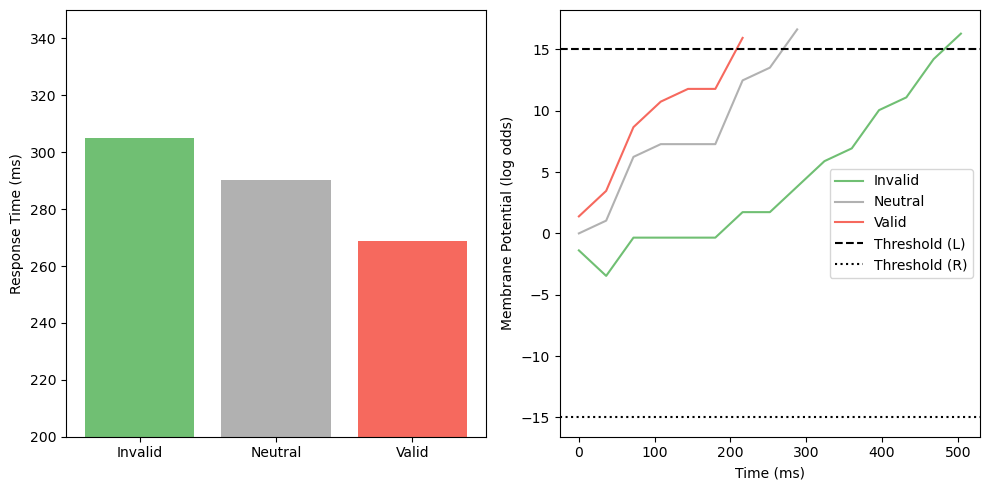

In [ ]:
# --- Run the Demo ---

# 1. Setup Model
model = PosnerModel(n_neurons=100, rate_high=40, rate_low=5, threshold=15, capacitance=2.0)

# 2. Simulation Parameters
conversion_factor = 36000 # Convert model time units to ms (empirically derived)
n_trials = 200
conditions = ['Invalid', 'Neutral', 'Valid']
results = {cond: [] for cond in conditions}

# 3. Run Simulations
for cond in conditions:
    for _ in range(n_trials):
        # Randomly choose a target location (Left/Right)
        target = np.random.choice(['Left', 'Right'])
        rt, _ = model.simulate_trial(cond, target)
        results[cond].append(rt * conversion_factor) # Convert to ms

# 4. Calculate Statistics
means = [np.mean(results[c]) for c in conditions]

# 5. Plot Results
plt.figure(figsize=(10, 5))

# Reaction times
plt.subplot(1, 2, 1)
colors = ['#4CAF50', '#9E9E9E', '#F44336'] # Green, Grey, Red
bars = plt.bar(conditions, means, capsize=5, color=colors, alpha=0.8)
plt.ylabel('Response Time (ms)')
plt.ylim(200, 350)

# Single trial trajectory
plt.subplot(1, 2, 2)
# Run one example trial for each condition to visualize
t_vec = np.arange(0, 1.0, 0.001) # Dummy time vector
for i, cond in enumerate(conditions):
    # Force 'Left' target for easier visualization of positive drift
    rt, traj = model.simulate_trial(cond, 'Left') 
    time_axis = np.arange(len(traj)) * model.dt * conversion_factor
    plt.plot(time_axis, traj, label=cond, color=colors[i], alpha=0.8, width=2)

plt.axhline(model.threshold, color='k', linestyle='--', label='Threshold (L)')
plt.axhline(-model.threshold, color='k', linestyle=':', label='Threshold (R)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (log odds)')
plt.legend(loc='center right')

plt.tight_layout()

plt.savefig("attentional_cueing.pdf", bbox_inches='tight')
plt.show()